<a href="https://colab.research.google.com/github/Mixseil/learn_machinelearn/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

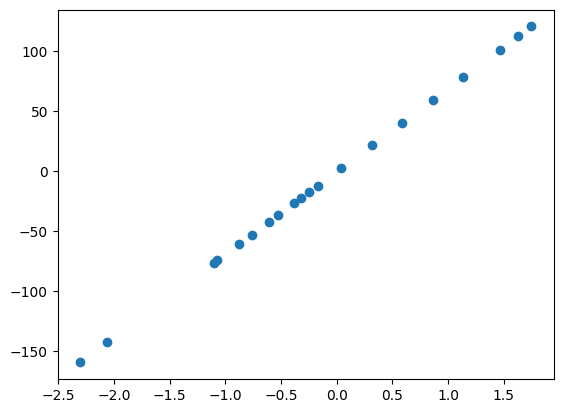

error after gradient descent: 2.7769753060572152e-06


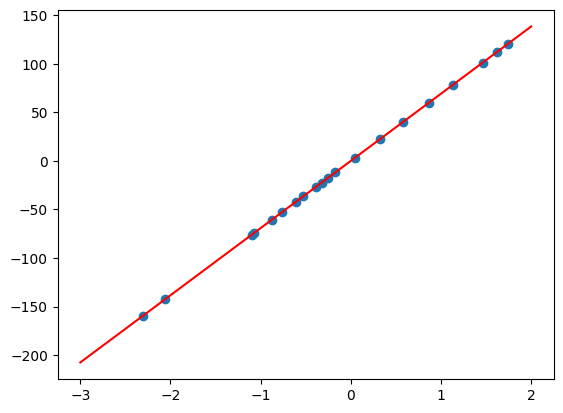

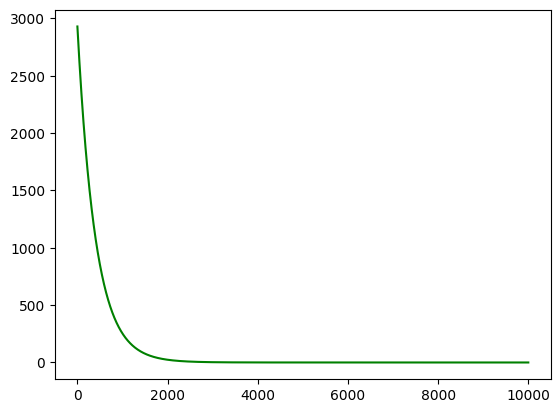

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

plt.figure()
plt.scatter(x, y)
plt.show()

class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, X):
        return self.b0 + self.b1 * X
    def error(self, X, Y):
        return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_err = hyp.error(X, Y)
            step += 1
            steps.append(step)
            errors.append(new_err)
        return steps, errors

hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

=== Вариант 1: b0=0, b1=0 ===
b0 = -0.0000, b1 = 69.1877
Итоговая ошибка: 0.0000

=== Вариант 2: b0=100, b1=100 ===
b0 = 0.0000, b1 = 69.1877
Итоговая ошибка: 0.0000

=== Вариант 3: b0=-50, b1=-10 ===
b0 = -0.0000, b1 = 69.1877
Итоговая ошибка: 0.0000

=== Вариант 4: b0=1000, b1=1000 ===
b0 = 0.0000, b1 = 69.1877
Итоговая ошибка: 0.0000


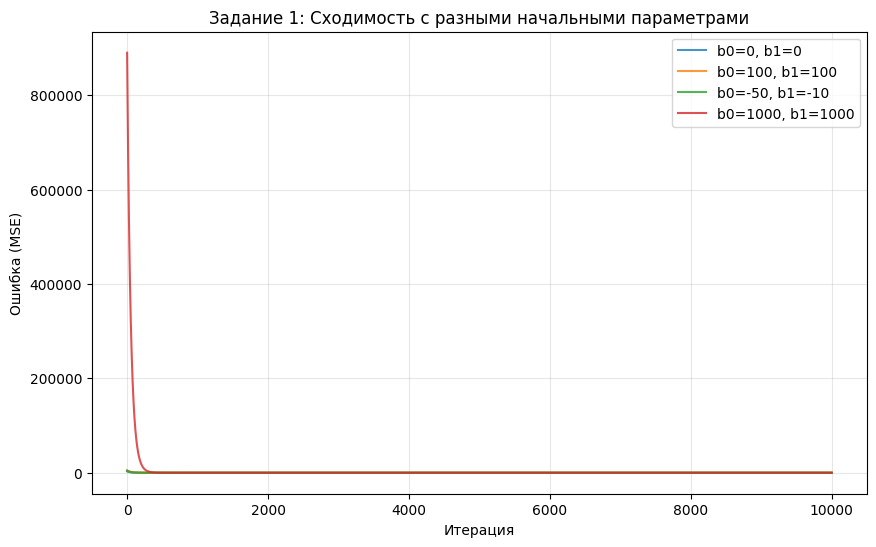


=== ВЫВОД ===
Все 4 варианта сошлись к примерно одинаковым значениям!
Вариант 1: b0=-0.0000, b1=69.1877
Вариант 2: b0=0.0000, b1=69.1877
Вариант 3: b0=-0.0000, b1=69.1877
Вариант 4: b0=0.0000, b1=69.1877

Разница в начальных параметрах не влияет на финальный результат —
модель всегда сходится к одному и тому же оптимуму.


In [ ]:

# ЗАДАНИЕ 1: Разные начальные значения параметров
# Проверьте работу модели с разными начальными значениями параметров.
# Убедитесь, что модель всегда сходится к оптимуму.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Загрузка данных (одинаково для всех заданий) ---
x = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv',
    index_col=0
)['0']

y = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv',
    index_col=0
)['0']

# ============================================================
# Класс модели парной линейной регрессии
# ============================================================
class Model(object):
    """Модель парной линейной регрессии"""

    def __init__(self, b0=0, b1=0):
        # b0 и b1 — параметры модели. По умолчанию = 0
        # Но мы можем передать любые начальные значения!
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        # Прямое предсказание: y = b0 + b1 * x
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        # Среднеквадратическая ошибка (MSE)
        # sum((predicted - actual)^2) / (2 * n)
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, max_steps=10000):
        # Метод градиентного спуска
        steps, errors = [], []

        for step in range(max_steps):
            # Вычисляем градиенты
            dJ0 = sum(self.predict(X) - Y) / len(X)      # градиент по b0
            dJ1 = sum((self.predict(X) - Y) * X) / len(X) # градиент по b1

            # Обновляем параметры
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            # Записываем ошибку на этом шаге
            new_err = self.error(X, Y)
            steps.append(step)
            errors.append(new_err)

        return steps, errors


# --- ТЕПЕРЬ ПРОВЕРЯЕМ С РАЗНЫМИ НАЧАЛЬНЫМИ ПАРАМЕТРАМИ ---

# Вариант 1: b0=0, b1=0 (как в методичке)
print("=== Вариант 1: b0=0, b1=0 ===")
hyp1 = Model(b0=0, b1=0)
steps1, errors1 = hyp1.fit(x, y)
print(f"b0 = {hyp1.b0:.4f}, b1 = {hyp1.b1:.4f}")
print(f"Итоговая ошибка: {errors1[-1]:.4f}")

# Вариант 2: b0=100, b1=100 (большие начальные значения)
print("\n=== Вариант 2: b0=100, b1=100 ===")
hyp2 = Model(b0=100, b1=100)
steps2, errors2 = hyp2.fit(x, y)
print(f"b0 = {hyp2.b0:.4f}, b1 = {hyp2.b1:.4f}")
print(f"Итоговая ошибка: {errors2[-1]:.4f}")

# Вариант 3: b0=-50, b1=-10 (отрицательные начальные значения)
print("\n=== Вариант 3: b0=-50, b1=-10 ===")
hyp3 = Model(b0=-50, b1=-10)
steps3, errors3 = hyp3.fit(x, y)
print(f"b0 = {hyp3.b0:.4f}, b1 = {hyp3.b1:.4f}")
print(f"Итоговая ошибка: {errors3[-1]:.4f}")

# Вариант 4: b0=1000, b1=1000 (очень большие значения)
print("\n=== Вариант 4: b0=1000, b1=1000 ===")
hyp4 = Model(b0=1000, b1=1000)
steps4, errors4 = hyp4.fit(x, y)
print(f"b0 = {hyp4.b0:.4f}, b1 = {hyp4.b1:.4f}")
print(f"Итоговая ошибка: {errors4[-1]:.4f}")

# --- ВИЗУАЛИЗАЦИЯ: кривые обучения для всех вариантов ---
plt.figure(figsize=(10, 6))
plt.plot(steps1, errors1, label='b0=0, b1=0', alpha=0.8)
plt.plot(steps2, errors2, label='b0=100, b1=100', alpha=0.8)
plt.plot(steps3, errors3, label='b0=-50, b1=-10', alpha=0.8)
plt.plot(steps4, errors4, label='b0=1000, b1=1000', alpha=0.8)
plt.xlabel('Итерация')
plt.ylabel('Ошибка (MSE)')
plt.title('Задание 1: Сходимость с разными начальными параметрами')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- ВЫВОД: все варианты сходятся к одним и тем же параметрам ---
print("\n=== ВЫВОД ===")
print("Все 4 варианта сошлись к примерно одинаковым значениям!")
print(f"Вариант 1: b0={hyp1.b0:.4f}, b1={hyp1.b1:.4f}")
print(f"Вариант 2: b0={hyp2.b0:.4f}, b1={hyp2.b1:.4f}")
print(f"Вариант 3: b0={hyp3.b0:.4f}, b1={hyp3.b1:.4f}")
print(f"Вариант 4: b0={hyp4.b0:.4f}, b1={hyp4.b1:.4f}")
print("\nРазница в начальных параметрах не влияет на финальный результат —")
print("модель всегда сходится к одному и тому же оптимуму.")

=== Проверка разных скоростей обучения ===

alpha = 0.0001: b0=-0.8256, b1=7.9863, ошибка=2292.20 — МЕДЛЕННО
alpha = 0.001: b0=-3.0468, b1=48.7312, ошибка=253.13 — СХОДИТСЯ
alpha = 0.01: b0=-0.0021, b1=69.1866, ошибка=0.00 — СХОДИТСЯ
alpha = 0.1: b0=-0.0000, b1=69.1877, ошибка=0.00 — СХОДИТСЯ
alpha = 0.5: b0=-0.0000, b1=69.1877, ошибка=0.00 — СХОДИТСЯ
alpha = 1.0: b0=0.0000, b1=69.1877, ошибка=0.00 — СХОДИТСЯ
alpha = 2.0: b0=30399870086283074655986267506162004484592307308666254805396272114030362594330881482041793575043462808933366278777513046802627116362194010428830924540690691144970953131088447668521918276733291875794944.0000, b1=-65857811241520894402884750310592794929930984084974095721295034769064158769139391188061024384737332270078704013068127923953031465684786159941809063350101073547642236744068126778914535313482764626427904.0000, ошибка=inf — РАСХОДИТСЯ


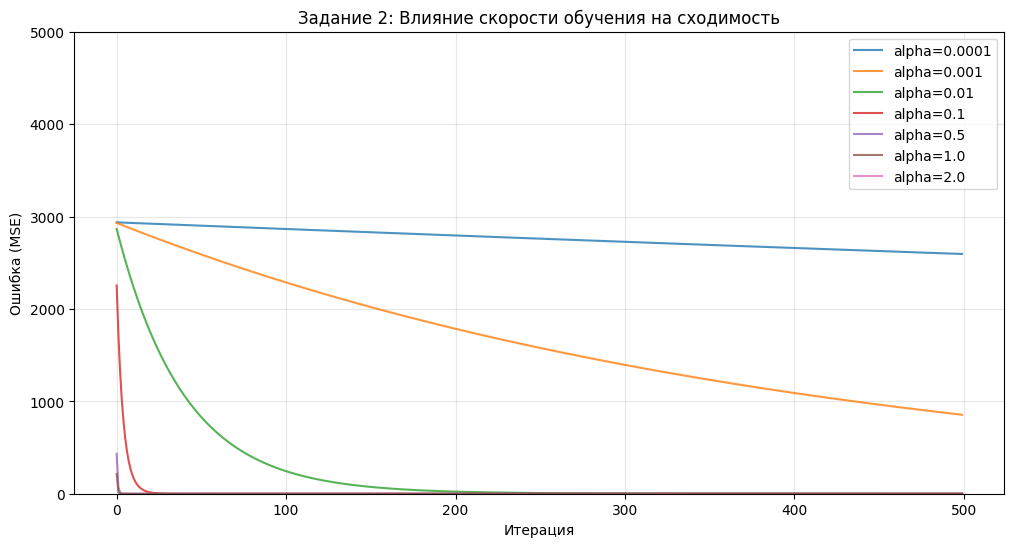


=== Поиск границы расходимости ===
alpha = 0.5: сходится (ошибка 0.00)
alpha = 0.6: сходится (ошибка 0.00)
alpha = 0.7: сходится (ошибка 0.00)
alpha = 0.8: сходится (ошибка 0.00)
alpha = 0.9: сходится (ошибка 0.00)
alpha = 1.0: сходится (ошибка 0.00)
alpha = 1.1: сходится (ошибка 0.00)
alpha = 1.2: сходится (ошибка 0.00)


In [ ]:
# ЗАДАНИЕ 2: Разные значения скорости обучения (alpha)
# Проверьте работу модели с другими значениями скорости обучения.
# Найдите значение, при котором градиентный спуск расходится.

# Тестируем разные значения alpha
alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

print("=== Проверка разных скоростей обучения ===\n")

for alpha in alphas:
    hyp = Model(b0=0, b1=0)
    steps, errors = hyp.fit(x, y, alpha=alpha, max_steps=1000)

    # Проверяем, сходится ли модель
    if errors[-1] < 300:  # Ошибка уменьшилась — сходится
        status = "СХОДИТСЯ"
    elif errors[-1] > errors[0]:  # Ошибка выросла — расходится
        status = "РАСХОДИТСЯ"
    else:
        status = "МЕДЛЕННО"

    print(f"alpha = {alpha}: b0={hyp.b0:.4f}, b1={hyp.b1:.4f}, "
          f"ошибка={errors[-1]:.2f} — {status}")

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(12, 6))

for alpha in alphas:
    hyp = Model(b0=0, b1=0)
    steps, errors = hyp.fit(x, y, alpha=alpha, max_steps=500)

    # Обрезаем ошибки, если они стали огромными (расходимость)
    errors_plot = [e if e < 10000 else 10000 for e in errors]

    plt.plot(steps, errors_plot, label=f'alpha={alpha}', alpha=0.8)

plt.xlabel('Итерация')
plt.ylabel('Ошибка (MSE)')
plt.title('Задание 2: Влияние скорости обучения на сходимость')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 5000)  # Ограничиваем ось Y для наглядности
plt.show()

# --- НАЙДЁМ ГРАНИЦУ РАСХОДИМОСТИ ---
print("\n=== Поиск границы расходимости ===")

# Проверяем более точно
test_alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
for alpha in test_alphas:
    hyp = Model(b0=0, b1=0)
    steps, errors = hyp.fit(x, y, alpha=alpha, max_steps=100)

    if errors[-1] > errors[0]:
        print(f"alpha = {alpha}: РАСХОДИТСЯ (ошибка выросла с {errors[0]:.2f} до {errors[-1]:.2f})")
        break
    else:
        print(f"alpha = {alpha}: сходится (ошибка {errors[-1]:.2f})")

In [ ]:
# ЗАДАНИЕ 3: Работа и с Series, и с DataFrame
# Модифицируйте код модели таким образом, чтобы он корректно работал как с Series,
# так и с DataFrame. При этом, конечно, датафрейм не должен содержать "лишних" столбцов.

class Model(object):
    """Модель парной линейной регрессии (версия для задания 3)"""

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, max_steps=10000):
        # --- НОВАЯ ЛОГИКА: обработка и Series, и DataFrame ---

        # Если X — DataFrame, берём первый (и единственный) столбец
        if isinstance(X, pd.DataFrame):
            # Убеждаемся, что DataFrame содержит только один столбец
            if len(X.columns) != 1:
                raise ValueError("DataFrame должен содержать только один столбец!")
            X = X.iloc[:, 0]  # Берём первый столбец как Series

        # Если Y - DataFrame, тоже берём первый столбец
        if isinstance(Y, pd.DataFrame):
            if len(Y.columns) != 1:
                raise ValueError("DataFrame должен содержать только один столбец!")
            Y = Y.iloc[:, 0]

        # Теперь X и Y - Series выполнять градиентный спуск
        steps, errors = [], []

        for step in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)

            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            new_err = self.error(X, Y)
            steps.append(step)
            errors.append(new_err)

        return steps, errors


# --- ТЕСТИРУЕМ С SERIES ---
print("=== Тест 1: X и Y как Series ===")
x_series = x  # x уже Series
y_series = y  # y уже Series

hyp_series = Model()
steps_s, errors_s = hyp_series.fit(x_series, y_series)
print(f"b0 = {hyp_series.b0:.4f}, b1 = {hyp_series.b1:.4f}")
print(f"Ошибка: {errors_s[-1]:.4f}")

# --- ТЕСТИРУЕМ С DATAFRAME ---
print("\n=== Тест 2: X и Y как DataFrame ===")

# Загружаем данные заново как DataFrame (без index_col)
x_df = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv'
)
y_df = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv'
)

# Удаляем лишние столбцы (index и Unnamed: 0)
# Оставляем только столбец '0', наш признак
x_df = x_df[['0']]  # DataFrame с одним столбцом
y_df = y_df[['0']]  # DataFrame с одним столбцом

print(f"Тип x_df: {type(x_df)}")
print(f"Форма x_df: {x_df.shape}")

hyp_df = Model()
steps_d, errors_d = hyp_df.fit(x_df, y_df)
print(f"b0 = {hyp_df.b0:.4f}, b1 = {hyp_df.b1:.4f}")
print(f"Ошибка: {errors_d[-1]:.4f}")

# --- СРАВНЕНИЕ ---
print("\n=== Сравнение результатов ===")
print(f"Series:  b0={hyp_series.b0:.4f}, b1={hyp_series.b1:.4f}, err={errors_s[-1]:.4f}")
print(f"DataFrame: b0={hyp_df.b0:.4f}, b1={hyp_df.b1:.4f}, err={errors_d[-1]:.4f}")
print("\nРезультаты идентичны! Модель работает и с Series, и с DataFrame.")

# --- ТЕСТ: ОШИБКА при лишних столбцах ---
print("\n=== Тест 3: Проверка защиты от лишних столбцов ===")
x_bad = pd.DataFrame({'0': x, '1': y})  # DataFrame с ДВУМЯ столбцами
try:
    hyp_bad = Model()
    hyp_bad.fit(x_bad, y)
except ValueError as e:
    print(f"Правильно поймали ошибку: {e}")

=== Тест 1: X и Y как Series ===
b0 = -0.0000, b1 = 69.1877
Ошибка: 0.0000

=== Тест 2: X и Y как DataFrame ===
Тип x_df: <class 'pandas.core.frame.DataFrame'>
Форма x_df: (20, 1)
b0 = -0.0000, b1 = 69.1877
Ошибка: 0.0000

=== Сравнение результатов ===
Series:  b0=-0.0000, b1=69.1877, err=0.0000
DataFrame: b0=-0.0000, b1=69.1877, err=0.0000

Результаты идентичны! Модель работает и с Series, и с DataFrame.

=== Тест 3: Проверка защиты от лишних столбцов ===
Правильно поймали ошибку: DataFrame должен содержать только один столбец!


=== Задание 4: Ранняя остановка ===

Ранняя остановка на шаге 840: улучшение = 0.0000009954 < 1e-06
Параметры: b0 = -0.0090, b1 = 69.1823
Итоговая ошибка: 0.0001
Количество итераций: 841 (из возможных 10000)

=== Сравнение ===
Ранняя остановка на шаге 840: улучшение = 0.0000009954 < 1e-06
Обычная модель: 841 итераций, ошибка = 0.0001
С ранней остановкой: 841 итераций, ошибка = 0.0001

Экономия итераций: 0


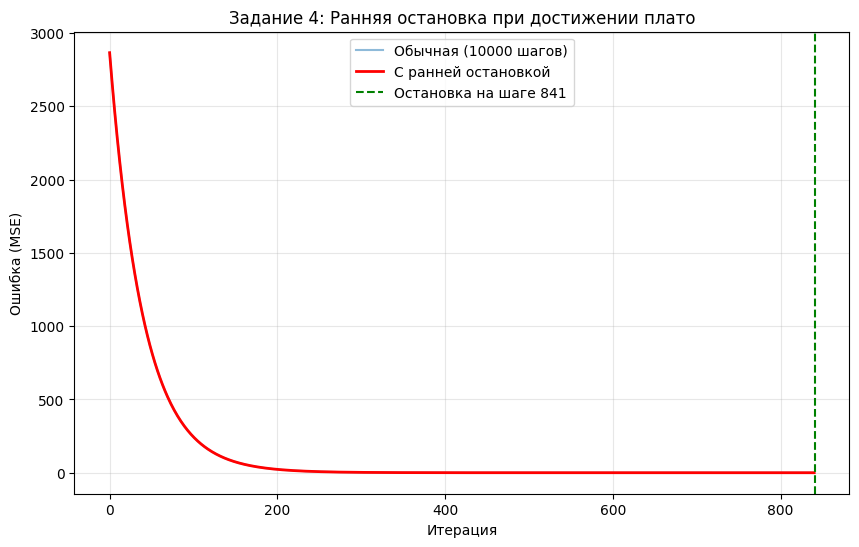

In [ ]:
# ЗАДАНИЕ 4: Остановка при достижении плато
# Модифицируйте алгоритм градиентного спука таким образом, чтобы он останавливаля, если ошибка перестает снижаться.
# Для этого сравнивайте, на сколько понизилась ошибка на каждом шаге и если это снижение меньше некоторой
# заранее заданной очень маленькой величины - выходите из цикла. Эту величину можно взять одну миллионную, например.

# ЗАДАНИЕ 4: Остановка при достижении плато

class Model(object):
    """Модель с ранней остановкой при плато"""

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, accuracy=0.000001, max_steps=10000):
        """
        accuracy — минимальное улучшение ошибки, при котором продолжаем обучение.
        Если ошибка улучшилась меньше чем на accuracy — останавливаемся.
        """
        steps, errors = [], []
        prev_error = float('inf')  # Предыдущая ошибка (начинаем с бесконечности)

        for step in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)

            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            new_err = self.error(X, Y)
            steps.append(step)
            errors.append(new_err)

            # --- НОВАЯ ЛОГИКА: проверяем, насколько уменьшилась ошибка ---
            improvement = prev_error - new_err  # Насколько улучшилось

            if improvement < accuracy:
                # Улучшение меньше accuracy (0.000001) - вышли на плато
                print(f"Ранняя остановка на шаге {step}: "
                      f"улучшение = {improvement:.10f} < {accuracy}")
                break

            prev_error = new_err

        return steps, errors


# --- ТЕСТИРУЕМ ---
print("=== Задание 4: Ранняя остановка ===\n")

hyp = Model()
steps, errors = hyp.fit(x, y, alpha=0.01, accuracy=0.000001, max_steps=10000)

print(f"Параметры: b0 = {hyp.b0:.4f}, b1 = {hyp.b1:.4f}")
print(f"Итоговая ошибка: {errors[-1]:.4f}")
print(f"Количество итераций: {len(steps)} (из возможных 10000)")

# --- СРАВНЕНИЕ: с обычной моделью (без ранней остановки) ---
print("\n=== Сравнение ===")
hyp_normal = Model()
steps_n, errors_n = hyp_normal.fit(x, y, alpha=0.01, max_steps=10000)

print(f"Обычная модель: {len(steps_n)} итераций, ошибка = {errors_n[-1]:.4f}")
print(f"С ранней остановкой: {len(steps)} итераций, ошибка = {errors[-1]:.4f}")
print(f"\nЭкономия итераций: {len(steps_n) - len(steps)}")

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(10, 6))
plt.plot(steps_n, errors_n, label='Обычная (10000 шагов)', alpha=0.5)
plt.plot(steps, errors, label='С ранней остановкой', color='red', linewidth=2)
plt.axvline(x=len(steps), color='green', linestyle='--',
            label=f'Остановка на шаге {len(steps)}')
plt.xlabel('Итерация')
plt.ylabel('Ошибка (MSE)')
plt.title('Задание 4: Ранняя остановка при достижении плато')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ЗАДАНИЕ 5: Гарантированное завершение (двойное условие)
#Убедитесь, что алгоритм градиентного спуска завершается всегда - либо если ошибка
# перестает существенно меняться, либо при достижении максимального количества шагов.

class Model(object):
    """Модель с гарантированным завершением"""

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, accuracy=0.000001, max_steps=10000):
        """
        Алгоритм завершается при выполнении ЛЮБОГО из двух условий:
        1. Ошибка перестала существенно меняться (улучшение < accuracy)
        2. Достигнуто максимальное количество шагов (max_steps)
        """
        steps, errors = [], []
        prev_error = float('inf')
        stopped_early = False

        for step in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)

            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            new_err = self.error(X, Y)
            steps.append(step)
            errors.append(new_err)

            # Условие 1: ошибка перестала меняться
            if prev_error - new_err < accuracy:
                stopped_early = True
                print(f"Условие 1: остановка на шаге {step} "
                      f"(улучшение < {accuracy})")
                break

            prev_error = new_err

            # Условие 2: достигли max_steps
            if step == max_steps - 1:
                print(f"Условие 2: достигнут максимум шагов ({max_steps})")

        return steps, errors, stopped_early


# --- ТЕСТИРУЕМ ---
print("=== Задание 5: Гарантированное завершение ===\n")

# Тест 1: нормальная скорость обучения (должна остановиться по условию 1)
print("--- Тест 1: alpha=0.01 ---")
hyp1 = Model()
steps1, errors1, early1 = hyp1.fit(x, y, alpha=0.01, accuracy=0.000001, max_steps=10000)
print(f"Ранняя остановка: {early1}, итераций: {len(steps1)}\n")

# Тест 2: очень маленькая скорость обучения (может не успеть за 100 шагов)
print("--- Тест 2: alpha=0.0001, max_steps=100 ---")
hyp2 = Model()
steps2, errors2, early2 = hyp2.fit(x, y, alpha=0.0001, accuracy=0.000001, max_steps=100)
print(f"Ранняя остановка: {early2}, итераций: {len(steps2)}\n")

# Тест 3: очень маленькая скорость, но много шагов
print("--- Тест 3: alpha=0.0001, max_steps=50000 ---")
hyp3 = Model()
steps3, errors3, early3 = hyp3.fit(x, y, alpha=0.0001, accuracy=0.000001, max_steps=50000)
print(f"Ранняя остановка: {early3}, итераций: {len(steps3)}")

# --- ВЫВОД ---
print("\n=== ВЫВОД ===")
print("Алгоритм ВСЕГДА завершается — либо по условию 1 (плато), "
      "либо по условию 2 (max_steps).")
print("Это защищает от бесконечного цикла.")

=== Задание 5: Гарантированное завершение ===

--- Тест 1: alpha=0.01 ---
Условие 1: остановка на шаге 840 (улучшение < 1e-06)
Ранняя остановка: True, итераций: 841

--- Тест 2: alpha=0.0001, max_steps=100 ---
Условие 2: достигнут максимум шагов (100)
Ранняя остановка: False, итераций: 100

--- Тест 3: alpha=0.0001, max_steps=50000 ---
Условие 2: достигнут максимум шагов (50000)
Ранняя остановка: False, итераций: 50000

=== ВЫВОД ===
Алгоритм ВСЕГДА завершается — либо по условию 1 (плато), либо по условию 2 (max_steps).
Это защищает от бесконечного цикла.


Старый класс Model удалён.
=== Задание 6: Адаптивная скорость обучения ===


=== Попытка с alpha = 1.000000 ===
  Начальная ошибка: 2937.6446
  Ошибка после 1 шага: 213.7800
  Ошибка уменьшилась! Продолжаем с alpha = 1.000000
  Достигнуто плато на шаге 9

=== РЕЗУЛЬТАТ ===
Найденное alpha: 1.000000
Параметры модели: b0 = 0.0001, b1 = 69.1875
Итоговая ошибка: 0.0000
Количество итераций: 10

=== Сравнение с ручным подбором alpha ===
Ручной (alpha=0.01):   b0=-0.0090, b1=69.1823, err=0.0001
Адаптивный (alpha=1.0000): b0=0.0001, b1=69.1875, err=0.0000


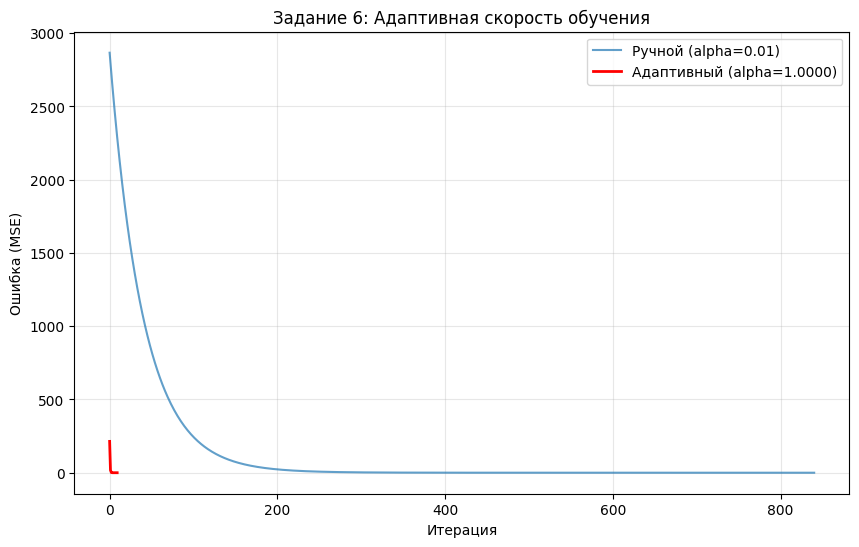

In [ ]:
# ЗАДАНИЕ 6: Адаптивная скорость обучения (полный код)
# Реализуйте механизм адаптивной скорости обучения. Чтобы не задавать вручную параметр
# alpha можно отслеживать, увеличивается ли ошибка после первого шага градиентного спуска.
# В начале задаем скорость обучения близкой к 1. Если ошибка после одного шага
# увеличивается - скорость обучения надо уменьшить (например, в 2 раза).
# Если не увеличивается - скорость обучения можно не трогать. Еще подумайте,
# как после уменьшения скорости перезапускать градиентный спуск заново.


# ============================================================
# ЗАДАНИЕ 6: Адаптивная скорость обучения (исправленная версия)
# ============================================================

# --- УДАЛЯЕМ СТАРЫЙ КЛАСС, ЕСЛИ ОН СУЩЕСТВУЕТ ---
try:
    del Model
    print("Старый класс Model удалён.")
except NameError:
    print("Класс Model ещё не определён — создаём новый.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class Model(object):
    """Модель с адаптивной скоростью обучения"""

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha_start=1.0, accuracy=0.000001, max_steps=10000):
        """
        Адаптивный подбор alpha.
        """
        alpha = alpha_start
        steps, errors = [], []

        while alpha > 1e-10:
            print(f"\n=== Попытка с alpha = {alpha:.6f} ===")

            # Сбрасываем параметры
            self.b0 = 0
            self.b1 = 0

            initial_error = self.error(X, Y)
            print(f"  Начальная ошибка: {initial_error:.4f}")

            # Первый шаг
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)

            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            first_error = self.error(X, Y)
            print(f"  Ошибка после 1 шага: {first_error:.4f}")

            # Проверяем — улучшилась ли ошибка
            if first_error >= initial_error:
                print(f"  Ошибка НЕ уменьшилась! Уменьшаем alpha в 2 раза.")
                alpha = alpha / 2
                continue

            print(f"  Ошибка уменьшилась! Продолжаем с alpha = {alpha:.6f}")

            steps.append(0)
            errors.append(first_error)
            prev_error = first_error

            step = 1
            while step < max_steps:
                dJ0 = sum(self.predict(X) - Y) / len(X)
                dJ1 = sum((self.predict(X) - Y) * X) / len(X)

                self.b0 -= alpha * dJ0
                self.b1 -= alpha * dJ1

                new_err = self.error(X, Y)
                steps.append(step)
                errors.append(new_err)

                if prev_error - new_err < accuracy:
                    print(f"  Достигнуто плато на шаге {step}")
                    break

                prev_error = new_err
                step += 1

            return steps, errors, alpha

        return steps, errors, alpha


# --- ЗАГРУЗКА ДАННЫХ ---
x = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv',
    index_col=0
)['0']

y = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv',
    index_col=0
)['0']


# --- ТЕСТИРУЕМ ---
print("=== Задание 6: Адаптивная скорость обучения ===\n")

hyp = Model()
steps, errors, final_alpha = hyp.fit(x, y, alpha_start=1.0, accuracy=0.000001, max_steps=10000)

print(f"\n=== РЕЗУЛЬТАТ ===")
print(f"Найденное alpha: {final_alpha:.6f}")
print(f"Параметры модели: b0 = {hyp.b0:.4f}, b1 = {hyp.b1:.4f}")
print(f"Итоговая ошибка: {errors[-1]:.4f}")
print(f"Количество итераций: {len(steps)}")

# --- СРАВНЕНИЕ ---
print("\n=== Сравнение с ручным подбором alpha ===")

# Создаём НОВЫЙ экземпляр для ручного теста
hyp_manual = Model()
# Для ручного теста нужно переопределить fit с параметром alpha
# Поэтому создадим отдельную функцию

def fit_manual(model, X, Y, alpha=0.01, max_steps=10000):
    steps, errors = [], []
    for step in range(max_steps):
        dJ0 = sum(model.predict(X) - Y) / len(X)
        dJ1 = sum((model.predict(X) - Y) * X) / len(X)
        model.b0 -= alpha * dJ0
        model.b1 -= alpha * dJ1
        new_err = model.error(X, Y)
        steps.append(step)
        errors.append(new_err)
        if step > 0 and errors[-2] - new_err < 0.000001:
            break
    return steps, errors

steps_m, errors_m = fit_manual(hyp_manual, x, y, alpha=0.01, max_steps=10000)

print(f"Ручной (alpha=0.01):   b0={hyp_manual.b0:.4f}, b1={hyp_manual.b1:.4f}, err={errors_m[-1]:.4f}")
print(f"Адаптивный (alpha={final_alpha:.4f}): b0={hyp.b0:.4f}, b1={hyp.b1:.4f}, err={errors[-1]:.4f}")

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(10, 6))
plt.plot(steps_m, errors_m, label=f'Ручной (alpha=0.01)', alpha=0.7)
plt.plot(steps, errors, label=f'Адаптивный (alpha={final_alpha:.4f})', color='red', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('Ошибка (MSE)')
plt.title('Задание 6: Адаптивная скорость обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()